# Model Evaluation & Comparison

1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

2. Load Dataset

In [3]:
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

3. Remove Unnecessary Columns

In [4]:
df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace =True
)

4. Encode Target

In [5]:
le = LabelEncoder()

df["Attrition"] = le.fit_transform(df["Attrition"])

5. Split Features and Target

In [6]:
x = df.drop("Attrition", axis = 1)
y = df["Attrition"]

6. Identify Numerical and Categorical Columns

In [7]:
numerical_columns = x.select_dtypes(include=["int64"]).columns
categorical_columns = x.select_dtypes(include=["object"]).columns

/var/folders/83/lyk88fr96bq5vfw5v_m3j0n40000gn/T/ipykernel_10230/2031502495.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x.select_dtypes(include=["object"]).columns


7. Create Preprocessor

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_columns
        )
    ]
)

8. Train-Test Split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

9. Create Model Dictionary

In [10]:
models = {
    "LogisticRegression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
}

10. Train Models

In [11]:
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("Preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(x_train, y_train)
    trained_models[name] = pipeline 

    print(f"{name} trained successfully.")

LogisticRegression trained successfully.
KNN trained successfully.
DecisionTree trained successfully.
Random Forest trained successfully.
SVM trained successfully.


11. Evaluate Every Model

In [14]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

12. Create Results DataFrame

In [15]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LogisticRegression,0.863946,0.640000,0.340426,0.444444,0.651994
1,KNN,0.836735,0.454545,0.106383,0.172414,0.541046
2,DecisionTree,0.758503,0.293103,0.361702,0.323810,0.597855
3,Random Forest,0.833333,0.416667,0.106383,0.169492,0.539021
4,SVM,0.857143,0.777778,0.148936,0.250000,0.570420


13. Sort Results

In [16]:
results_df.sort_values(
    by = "F1 Score",
    ascending=False,
    inplace=True
)

results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LogisticRegression,0.863946,0.640000,0.340426,0.444444,0.651994
1,DecisionTree,0.758503,0.293103,0.361702,0.323810,0.597855
2,SVM,0.857143,0.777778,0.148936,0.250000,0.570420
3,KNN,0.836735,0.454545,0.106383,0.172414,0.541046
4,Random Forest,0.833333,0.416667,0.106383,0.169492,0.539021


### Key Points

- Sorted all models based on **F1 Score** in descending order.
- Since the Employee Attrition dataset is **imbalanced**, **F1 Score** was used as the primary evaluation metric because it provides a balanced measure of both Precision and Recall, making model comparison more reliable than Accuracy alone.

14. Plot Comparison

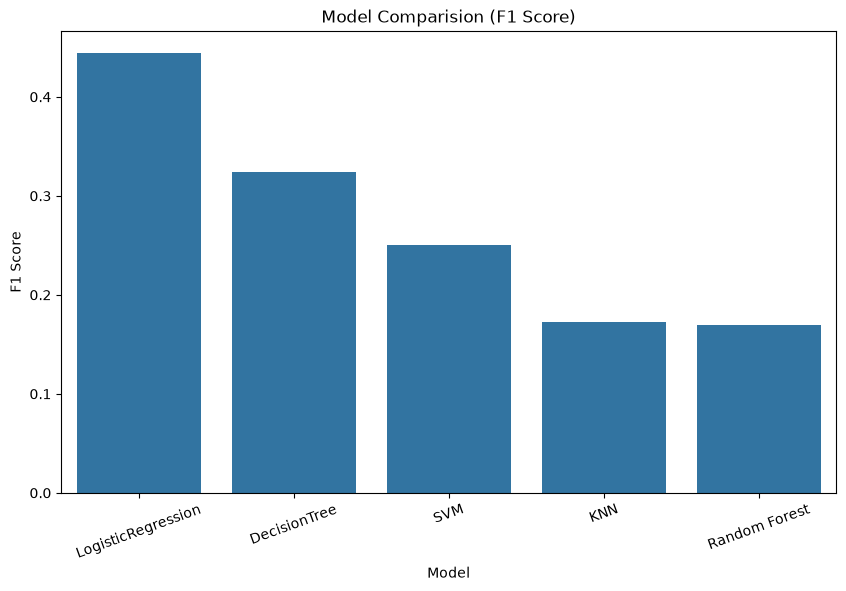

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparision (F1 Score)")

plt.xticks(rotation=20)
plt.show()

15. Confusion Matrix

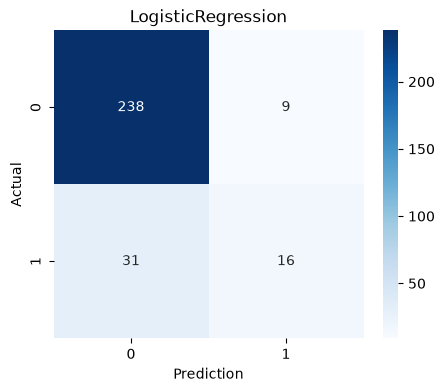

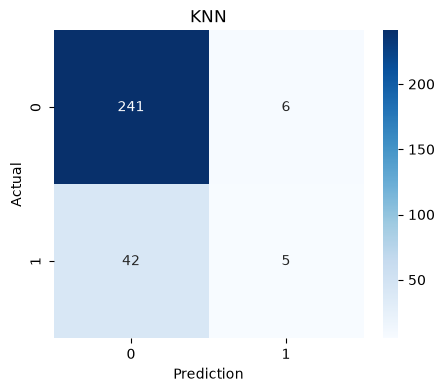

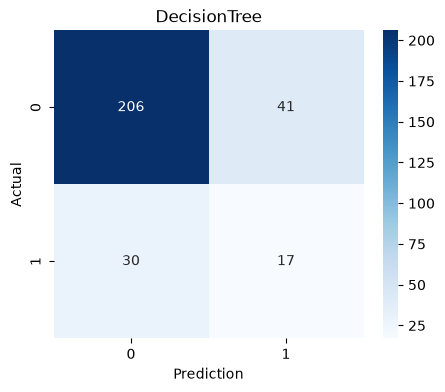

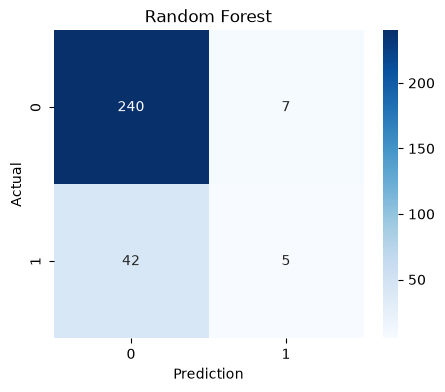

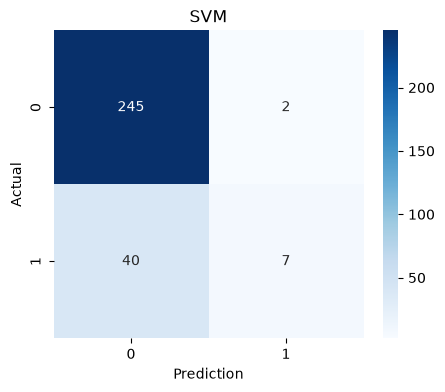

In [18]:
for name, model in trained_models.items():
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot = True,
        fmt = "d",
        cmap = "Blues"
    )
    plt.title(name)
    plt.xlabel("Prediction")
    plt.ylabel("Actual")
    plt.show()


16. Classification Report

In [20]:
for name, model in trained_models.items():
    print("="*60)
    print(name)
    y_pred = model.predict(x_test)
    print(classification_report(y_test, y_pred))

LogisticRegression
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.64      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.76      0.65      0.68       294
weighted avg       0.85      0.86      0.85       294

KNN
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294

DecisionTree
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       247
           1       0.29      0.36      0.32        47

    accuracy                           0.76       294
   macro avg       0.58      0.60      0.59       294
weighted avg       0.78      0.76     

# Summary 

## Objective
Evaluate multiple machine learning classification models using different performance metrics and identify the most suitable model for predicting employee attrition.

---

## Models Evaluated

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

---

## Evaluation Metrics Used

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

---

## Model Performance

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|--------|---------:|----------:|--------:|----------:|---------:|
| Logistic Regression | **86.39%** | **64.00%** | **34.04%** | **44.44%** | **65.20%** |
| Decision Tree | 75.85% | 29.31% | **36.17%** | 32.38% | 59.79% |
| SVM | 85.71% | **77.78%** | 14.89% | 25.00% | 57.04% |
| KNN | 83.67% | 45.45% | 10.64% | 17.24% | 54.10% |
| Random Forest | 83.33% | 41.67% | 10.64% | 16.95% | 53.90% |

---

## Business Analysis

The dataset is imbalanced, with significantly fewer employees leaving the organization than staying.

Because of this imbalance, accuracy alone is not a reliable performance metric.

The objective of this project is to identify employees who are likely to leave the company. Therefore, Recall and F1 Score become more important than Accuracy.

---

## Observations

- Logistic Regression achieved the highest overall F1 Score and the highest ROC-AUC score.
- Decision Tree achieved the highest Recall but suffered from lower Precision and Accuracy.
- SVM achieved very high Precision but failed to identify many employees who actually left.
- KNN and Random Forest achieved good Accuracy but performed poorly in detecting the minority class.
- Accuracy alone can be misleading for imbalanced datasets.

---

## Final Model Selection

Based on the evaluation metrics, **Logistic Regression** was selected as the best baseline model because it provided the most balanced trade-off between Precision, Recall, F1 Score, Accuracy, and ROC-AUC.

Although Decision Tree achieved slightly higher Recall, its overall performance was lower than Logistic Regression.

---

## Key Learnings

- Multiple evaluation metrics should always be considered while selecting a classification model.
- F1 Score provides a better assessment than Accuracy for imbalanced classification problems.
- Confusion Matrix and Classification Report provide deeper insights into model performance than Accuracy alone.
- Model selection should always align with the business objective instead of relying solely on the highest Accuracy.